# Classification de CVs — Prédiction de `passed_next_stage`

**Objectif :** prédire si un CV passe à l'étape suivante du processus de recrutement.

**Métrique principale : Accuracy** (taux global de bonnes prédictions).  
> ⚠️ Sur données déséquilibrées, l'accuracy seule peut être trompeuse. Elle est ici complétée par ROC-AUC et la courbe Précision-Recall pour un diagnostic complet.

**Pipeline :**
1. Chargement & exploration
2. Feature engineering
3. Preprocessing (StandardScaler + OHE + TF-IDF)
4. Régression Logistique — baseline L2, puis L1 régularisée
5. Validation du seuil sur fold dédié + learning curve
6. Modèles ensemblistes (Random Forest, Gradient Boosting)
7. Calibration (Platt) + interprétabilité SHAP
8. Conclusion & modèle retenu

## 1. Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score,
    RandomizedSearchCV, learning_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score,
    precision_recall_curve, average_precision_score,
)
from statsmodels.stats.outliers_influence import variance_inflation_factor

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import shap

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
RANDOM_STATE = 42

## 2. Chargement & exploration

In [2]:
df = pd.read_csv('../data/cv_dataset.csv')

print(f'Shape : {df.shape}')
print('\nTypes & valeurs manquantes :')
print(pd.concat([df.dtypes.rename('dtype'), df.isnull().sum().rename('nulls')], axis=1))
df.head()

Shape : (200, 21)

Types & valeurs manquantes :
                           dtype  nulls
cv_id                        str      0
age                        int64      0
distance_ville_haute_km  float64      0
target_role                  str      0
total_experience_years   float64      0
total_gap_months           int64      0
nb_gaps                    int64      0
education_degree             str      0
education_field              str      0
education_school             str      0
education_score            int64      0
skills                       str      0
certifications               str      0
number_of_experiences      int64      0
lang_fr                    int64      0
lang_en                    int64      0
lang_de                    int64      0
lang_es                    int64      0
lang_it                    int64      0
lang_other_score_sum       int64      0
passed_next_stage          int64      0


,cv_id,age,distance_ville_haute_km,target_role,total_experience_years,total_gap_months,nb_gaps,education_degree,education_field,education_school,...,skills,certifications,number_of_experiences,lang_fr,lang_en,lang_de,lang_es,lang_it,lang_other_score_sum,passed_next_stage
0,cv_0001.txt,30,7585.14,Software Engineer,2.4,14,1,Bachelor of Science,Computer Science,Indian Institute of Technology Delhi,...,"C#, Confluence, SQL, Git, Python, ETL basics, ...",Professional Scrum Developer,2,0,6,0,0,0,0,0
1,cv_0002.txt,39,1087.96,Frontend Developer,6.5,25,2,Master of Science,Information Technology,Indian Institute of Technology Delhi,...,"Testing Library, Next.js, React, JavaScript, H...","Professional Scrum Master I, AWS Cloud Practit...",3,6,5,0,0,0,0,0
2,cv_0003.txt,34,8038.04,Backend Developer,7.3,24,2,Master of Science,Information Technology,Trinity College Dublin,...,"REST APIs, Java, Docker, Redis, PostgreSQL, AP...","Scrum Fundamentals Certified, ITIL Foundation,...",3,0,6,0,0,0,0,1
3,cv_0004.txt,34,319.28,Software Engineer,7.3,0,0,Bachelor of Science,Software Engineering,Politecnico di Milano,...,"Docker, SQL, Java, System integration, Object-...",Professional Scrum Developer,1,0,5,6,0,0,0,0
4,cv_0005.txt,39,158.95,Software Engineer,9.5,32,2,Bachelor of Science,Computer Science,University of Colorado Boulder,...,"REST APIs, Python, SQL, Unit testing, Document...","AWS Certified Developer, Azure Developer Assoc...",3,0,6,3,0,0,0,1


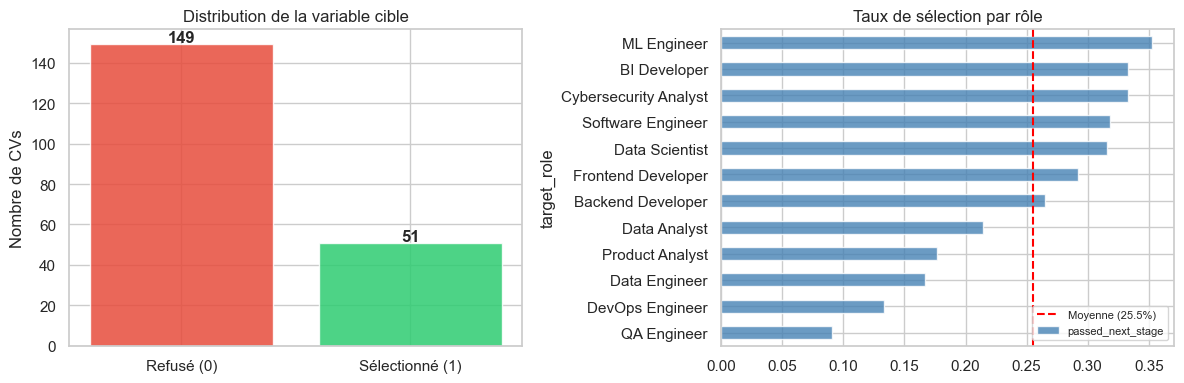

Taux de sélection global : 25.5%


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['passed_next_stage'].value_counts()
axes[0].bar(['Refusé (0)', 'Sélectionné (1)'], counts.values,
            color=['#e74c3c', '#2ecc71'], alpha=0.85, edgecolor='white')
axes[0].set_title('Distribution de la variable cible')
axes[0].set_ylabel('Nombre de CVs')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

role_rate = df.groupby('target_role')['passed_next_stage'].mean().sort_values()
role_rate.plot(kind='barh', ax=axes[1], color='steelblue', alpha=0.8)
axes[1].set_title('Taux de sélection par rôle')
axes[1].axvline(df['passed_next_stage'].mean(), color='red', linestyle='--',
                label=f"Moyenne ({df['passed_next_stage'].mean():.1%})")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()
print(f"Taux de sélection global : {df['passed_next_stage'].mean():.1%}")

## 3. Feature Engineering

`avg_gap_duration` et `gap_ratio` remplacent `nb_gaps` / `total_gap_months` pour éviter leur colinéarité.  
`has_certif` est conservé comme signal binaire fort.

In [4]:
# Durée moyenne d'un gap (résout la colinéarité nb_gaps / total_gap_months)
df['avg_gap_duration'] = df['total_gap_months'] / (df['nb_gaps'] + 1)

# Part de la carrière en gap — signal de stabilité
df['gap_ratio'] = df['total_gap_months'] / (
    df['total_experience_years'] * 12 + df['total_gap_months'] + 1
)

# Nombre de skills distincts listés
df['skills_count'] = df['skills'].fillna('').apply(
    lambda x: len([s.strip() for s in x.split(',') if s.strip()])
)

# Présence de certifications (binaire)
df['has_certif'] = df['certifications'].fillna('').str.strip().ne('').astype(int)

print(df[['avg_gap_duration', 'gap_ratio', 'skills_count', 'has_certif']].describe())

       avg_gap_duration   gap_ratio  skills_count  has_certif
count        200.000000  200.000000    200.000000       200.0
mean           4.726667    0.142159     12.605000         1.0
std            4.685266    0.155486      1.790251         0.0
min            0.000000    0.000000      8.000000         1.0
25%            0.000000    0.000000     11.000000         1.0
50%            5.166667    0.137668     13.000000         1.0
75%            9.000000    0.261118     14.000000         1.0
max           14.000000    0.851064     17.000000         1.0


In [5]:
TARGET    = 'passed_next_stage'
DROP_COLS = ['cv_id']

# avg_gap_duration et gap_ratio remplacent nb_gaps et total_gap_months
# has_certif conservé (signal binaire pertinent)
NUMERIC_FEATURES = [
    'age', 'distance_ville_haute_km', 'total_experience_years',
    'nb_gaps', 'gap_ratio', 'education_score', 'number_of_experiences',
    'skills_count', 'has_certif',
    'lang_fr', 'lang_en', 'lang_de', 'lang_es', 'lang_it', 'lang_other_score_sum',
]

# education_school exclu : cardinalité trop haute pour le volume disponible
CATEGORICAL_FEATURES = ['target_role', 'education_degree', 'education_field']

TEXT_SKILLS         = 'skills'
TEXT_CERTIFICATIONS = 'certifications'

X = df.drop(columns=DROP_COLS + [TARGET])
y = df[TARGET]

print(f"Numériques : {len(NUMERIC_FEATURES)}  |  Catégorielles : {len(CATEGORICAL_FEATURES)}  |  Texte : 2")
print(f"X : {X.shape}  |  y : {y.shape}  |  taux positifs : {y.mean():.1%}")

Numériques : 15  |  Catégorielles : 3  |  Texte : 2
X : (200, 23)  |  y : (200,)  |  taux positifs : 25.5%


## 4. Split train / validation / test

On réserve un **fold de validation** distinct du test pour :
- optimiser le seuil de décision (éviter le data leakage)
- construire la learning curve

Split final : 60 % train — 20 % validation — 20 % test.

In [6]:
# Première coupe : 80 % train+val / 20 % test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

# Deuxième coupe : 75 % du reste → train, 25 % → val  (soit 60/20/20 global)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=RANDOM_STATE, stratify=y_trainval
)

print(f"Train : {len(X_train):>4}  |  positifs : {y_train.mean():.1%}")
print(f"Val   : {len(X_val):>4}  |  positifs : {y_val.mean():.1%}")
print(f"Test  : {len(X_test):>4}  |  positifs : {y_test.mean():.1%}")

Train :  120  |  positifs : 25.8%
Val   :   40  |  positifs : 25.0%
Test  :   40  |  positifs : 25.0%


## 5. Preprocessing Pipeline

In [7]:
for col in [TEXT_SKILLS, TEXT_CERTIFICATIONS]:
    for split in [X_train, X_val, X_test]:
        split[col] = split[col].fillna('').str.lower().str.replace(r'[^\w\s,]', '', regex=True)

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

# token_pattern étendu pour capturer les termes techniques (C++, .NET, C#)
skills_tfidf = TfidfVectorizer(max_features=20, token_pattern=r'[a-zA-Z0-9#+\-\.]+', min_df=2)
certif_tfidf = TfidfVectorizer(max_features=15, token_pattern=r'[a-zA-Z0-9#+\-\.]+', min_df=2)

preprocessor = ColumnTransformer([
    ('num',    numeric_pipeline,     NUMERIC_FEATURES),
    ('cat',    categorical_pipeline, CATEGORICAL_FEATURES),
    ('skills', skills_tfidf,         TEXT_SKILLS),
    ('certif', certif_tfidf,         TEXT_CERTIFICATIONS),
], remainder='drop')

print('Preprocessor défini ✓')

Preprocessor défini ✓


## 6. Régression Logistique

### 6.1 Analyse VIF — multicolinéarité sur features numériques

In [8]:
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])
X_num_scaled = pd.DataFrame(
    num_pipe.fit_transform(X_train[NUMERIC_FEATURES]),
    columns=NUMERIC_FEATURES
)

vif_data = pd.DataFrame({
    'feature': NUMERIC_FEATURES,
    'VIF': [variance_inflation_factor(X_num_scaled.values, i)
            for i in range(X_num_scaled.shape[1])]
}).sort_values('VIF', ascending=False)

print('VIF — seuil critique : 5 (problématique), 10 (sévère)')
print(vif_data.to_string(index=False))

VIF — seuil critique : 5 (problématique), 10 (sévère)
                feature        VIF
                nb_gaps 111.285647
  number_of_experiences 110.501378
   lang_other_score_sum   5.928910
                lang_en   5.191625
                lang_fr   5.006257
              gap_ratio   4.667530
                lang_it   4.322167
                lang_de   4.320915
                    age   4.262928
 total_experience_years   4.132269
                lang_es   1.675674
        education_score   1.171193
           skills_count   1.145583
distance_ville_haute_km   1.125511
             has_certif        NaN


### 6.2 Features V2

On retire les features à fort VIF identifiées ci-dessus.  
`avg_gap_duration` (fort VIF, redondante avec `gap_ratio`) et `number_of_experiences` sont exclues.

In [9]:
# avg_gap_duration retirée (fort VIF), number_of_experiences retirée (redondante)
# has_certif maintenu — signal binaire indépendant, faible colinéarité
NUMERIC_FEATURES_V2 = [
    'age', 'distance_ville_haute_km', 'total_experience_years',
    'nb_gaps', 'gap_ratio', 'education_score', 'skills_count', 'has_certif',
    'lang_fr', 'lang_en', 'lang_de', 'lang_es', 'lang_it', 'lang_other_score_sum',
]

def build_preprocessor(numeric_features):
    """Construit un ColumnTransformer avec les features numériques fournies."""
    return ColumnTransformer([
        ('num',    Pipeline([('imputer', SimpleImputer(strategy='median')),
                             ('scaler',  StandardScaler())]),
                  numeric_features),
        ('cat',    Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                             ('ohe',     OneHotEncoder(handle_unknown='ignore',
                                                       sparse_output=False))]),
                  CATEGORICAL_FEATURES),
        ('skills', TfidfVectorizer(max_features=20,
                                   token_pattern=r'[a-zA-Z0-9#+\-\.]+', min_df=2),
                  TEXT_SKILLS),
        ('certif', TfidfVectorizer(max_features=15,
                                   token_pattern=r'[a-zA-Z0-9#+\-\.]+', min_df=2),
                  TEXT_CERTIFICATIONS),
    ], remainder='drop')

preprocessor_v2 = build_preprocessor(NUMERIC_FEATURES_V2)
print(f'Features numériques v2 : {len(NUMERIC_FEATURES_V2)}')

Features numériques v2 : 14


### 6.3 LR v1 — baseline L2

SMOTE est appliqué **uniquement dans le pipeline d'entraînement**, après le split, pour éviter tout data leakage.  
On n'utilise pas `LogisticRegressionCV` ici afin que SMOTE ne contamine pas la CV interne.

In [10]:
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

lr_v1 = ImbPipeline([
    ('preprocessor', build_preprocessor(NUMERIC_FEATURES)),
    ('smote',        SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
    ('classifier',   LogisticRegression(
                         C=1.0, penalty='l2', solver='lbfgs',
                         max_iter=1000, random_state=RANDOM_STATE,
                     )),
])

# CV sur X_train uniquement — X_val et X_test ne sont jamais vus ici
cv_acc_v1 = cross_val_score(lr_v1, X_train, y_train, cv=cv5, scoring='accuracy')
print(f'CV Accuracy v1 (5 folds) : {cv_acc_v1.mean():.3f} ± {cv_acc_v1.std():.3f}')

lr_v1.fit(X_train, y_train)
y_pred_v1  = lr_v1.predict(X_val)
y_proba_v1 = lr_v1.predict_proba(X_val)[:, 1]

print('\n=== LR v1 — baseline L2 (éval. sur Val) ===')
print(classification_report(y_val, y_pred_v1, target_names=['Refusé', 'Sélectionné']))
print(f'Accuracy : {accuracy_score(y_val, y_pred_v1):.3f}  |  ROC-AUC : {roc_auc_score(y_val, y_proba_v1):.3f}')

CV Accuracy v1 (5 folds) : 0.625 ± 0.059

=== LR v1 — baseline L2 (éval. sur Val) ===
              precision    recall  f1-score   support

      Refusé       0.84      0.70      0.76        30
 Sélectionné       0.40      0.60      0.48        10

    accuracy                           0.68        40
   macro avg       0.62      0.65      0.62        40
weighted avg       0.73      0.68      0.69        40

Accuracy : 0.675  |  ROC-AUC : 0.780


### 6.4 LR v2 — L1 + ElasticNet

**L1** : sélection implicite de features (coefficients poussés à 0).  
**ElasticNet** : compromis L1+L2, meilleure stabilité quand une colinéarité résiduelle subsiste.  
`C` est optimisé via `RandomizedSearchCV` (scoring `accuracy`) — séparé de SMOTE pour éviter la contamination de la CV interne.

In [11]:
from sklearn.model_selection import RandomizedSearchCV

# Grille commune L1, L2, ElasticNet
lr_param_grid = [
    {'classifier__penalty': ['l1'],        'classifier__C': np.logspace(-3, 2, 30),
     'classifier__solver':  ['liblinear'], 'classifier__l1_ratio': [None]},
    {'classifier__penalty': ['l2'],        'classifier__C': np.logspace(-3, 2, 30),
     'classifier__solver':  ['lbfgs'],    'classifier__l1_ratio': [None]},
    {'classifier__penalty': ['elasticnet'],'classifier__C': np.logspace(-3, 2, 15),
     'classifier__solver':  ['saga'],     'classifier__l1_ratio': [0.15, 0.5, 0.85]},
]

lr_base_pipeline = ImbPipeline([
    ('preprocessor', preprocessor_v2),
    ('smote',        SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
    ('classifier',   LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])

lr_search = RandomizedSearchCV(
    lr_base_pipeline,
    lr_param_grid,
    n_iter=50,
    cv=cv5,
    scoring='accuracy',   # aligné sur l'objectif métier
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
lr_search.fit(X_train, y_train)

print(f'Meilleurs params : {lr_search.best_params_}')
print(f'Best CV Accuracy : {lr_search.best_score_:.3f}')

lr_v2 = lr_search.best_estimator_
y_pred_v2  = lr_v2.predict(X_val)
y_proba_v2 = lr_v2.predict_proba(X_val)[:, 1]

print('\n=== LR v2 — meilleur modèle (éval. sur Val) ===')
print(classification_report(y_val, y_pred_v2, target_names=['Refusé', 'Sélectionné']))
print(f'Accuracy : {accuracy_score(y_val, y_pred_v2):.3f}  |  ROC-AUC : {roc_auc_score(y_val, y_proba_v2):.3f}')

Meilleurs params : {'classifier__solver': 'liblinear', 'classifier__penalty': 'l1', 'classifier__l1_ratio': None, 'classifier__C': np.float64(0.001)}
Best CV Accuracy : 0.742

=== LR v2 — meilleur modèle (éval. sur Val) ===
              precision    recall  f1-score   support

      Refusé       0.75      1.00      0.86        30
 Sélectionné       0.00      0.00      0.00        10

    accuracy                           0.75        40
   macro avg       0.38      0.50      0.43        40
weighted avg       0.56      0.75      0.64        40

Accuracy : 0.750  |  ROC-AUC : 0.500


### 6.5 Learning Curve

Diagnostique biais / variance sur la LR v2 : si les courbes train et val convergent loin du plafond → biais élevé (underfitting) ; si elles divergent → variance élevée (overfitting).

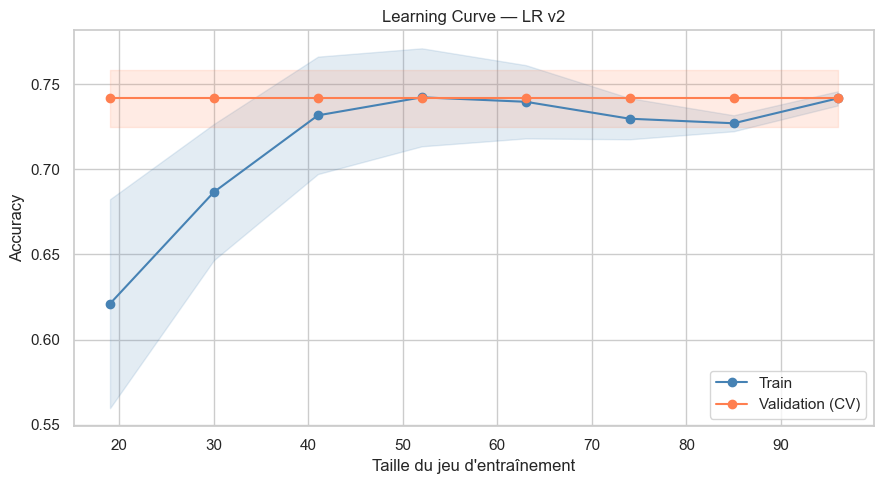

In [21]:
train_sizes, train_scores, val_scores = learning_curve(
    lr_v2, X_train, y_train,
    cv=cv5,
    scoring='accuracy',
    train_sizes=np.linspace(0.2, 1.0, 8),
    n_jobs=-1,
)

train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
val_mean,   val_std   = val_scores.mean(axis=1),   val_scores.std(axis=1)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Train')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                 alpha=0.15, color='steelblue')
plt.plot(train_sizes, val_mean, 'o-', color='coral', label='Validation (CV)')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                 alpha=0.15, color='coral')
plt.xlabel('Taille du jeu d\'entraînement')
plt.ylabel('Accuracy')
plt.title('Learning Curve — LR v2')
plt.legend()
plt.tight_layout()
plt.show()

### 6.6 Optimisation du seuil — sur le fold de validation

Le seuil est sélectionné sur `X_val` (jamais vu à l'entraînement) puis appliqué **une seule fois** sur `X_test`.  
On maximise l'**accuracy** au seuil, cohérent avec l'objectif métier.

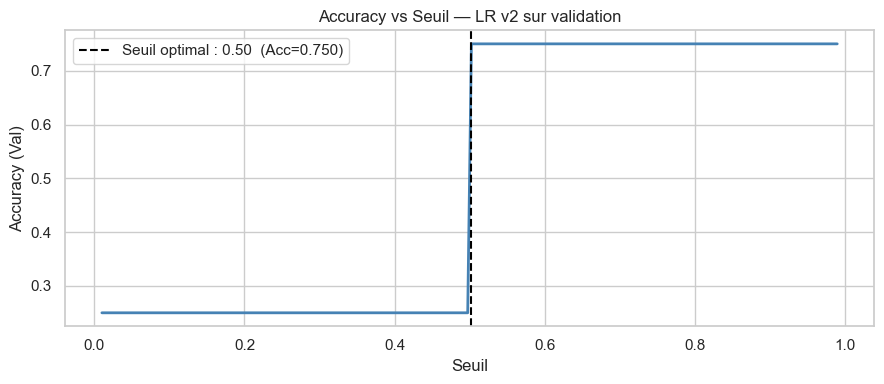

Seuil optimal : 0.502  |  Accuracy val : 0.750


In [22]:
def find_best_threshold_accuracy(y_true, y_proba):
    """Renvoie le seuil maximisant l'accuracy sur (y_true, y_proba)."""
    thresholds = np.linspace(0.01, 0.99, 200)
    accs = [accuracy_score(y_true, (y_proba >= t).astype(int)) for t in thresholds]
    best_idx = int(np.argmax(accs))
    return thresholds[best_idx], accs[best_idx]

best_threshold, best_val_acc = find_best_threshold_accuracy(y_val, y_proba_v2)

# Visualisation accuracy vs seuil
thresholds_plot = np.linspace(0.01, 0.99, 200)
accs_plot = [accuracy_score(y_val, (y_proba_v2 >= t).astype(int)) for t in thresholds_plot]

plt.figure(figsize=(9, 4))
plt.plot(thresholds_plot, accs_plot, color='steelblue', lw=2)
plt.axvline(best_threshold, color='black', linestyle='--', lw=1.5,
            label=f'Seuil optimal : {best_threshold:.2f}  (Acc={best_val_acc:.3f})')
plt.xlabel('Seuil')
plt.ylabel('Accuracy (Val)')
plt.title('Accuracy vs Seuil — LR v2 sur validation')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Seuil optimal : {best_threshold:.3f}  |  Accuracy val : {best_val_acc:.3f}')

### 6.7 Évaluation finale sur le jeu de test

Le seuil calibré sur `X_val` est appliqué ici **pour la première et unique fois** sur `X_test`.

In [14]:
def metrics_row(name, y_true, y_pred, y_proba):
    return {
        'Modèle':       name,
        'Accuracy':     round(accuracy_score(y_true, y_pred), 3),
        'Précision(1)': round(precision_score(y_true, y_pred, pos_label=1, zero_division=0), 3),
        'Recall(1)':    round(recall_score(y_true, y_pred,    pos_label=1, zero_division=0), 3),
        'F1(1)':        round(f1_score(y_true, y_pred,        pos_label=1, zero_division=0), 3),
        'ROC-AUC':      round(roc_auc_score(y_true, y_proba), 3),
    }

# Prédictions finales sur test
y_proba_v1_test = lr_v1.predict_proba(X_test)[:, 1]
y_proba_v2_test = lr_v2.predict_proba(X_test)[:, 1]

y_pred_v1_test     = lr_v1.predict(X_test)
y_pred_v2_test     = lr_v2.predict(X_test)                          # seuil 0.5
y_pred_v2_thresh   = (y_proba_v2_test >= best_threshold).astype(int) # seuil optimisé

comparison = pd.DataFrame([
    metrics_row('LR v1 — L2, seuil 0.5',              y_test, y_pred_v1_test,   y_proba_v1_test),
    metrics_row('LR v2 — L1/EN, seuil 0.5',           y_test, y_pred_v2_test,   y_proba_v2_test),
    metrics_row(f'LR v2 — L1/EN, seuil {best_threshold:.2f}', y_test, y_pred_v2_thresh, y_proba_v2_test),
]).set_index('Modèle')

print('=== Comparatif LR — jeu de test ===')
print(comparison.to_string())

=== Comparatif LR — jeu de test ===
                           Accuracy  Précision(1)  Recall(1)  F1(1)  ROC-AUC
Modèle                                                                      
LR v1 — L2, seuil 0.5          0.65         0.357        0.5  0.417    0.683
LR v2 — L1/EN, seuil 0.5       0.75         0.000        0.0  0.000    0.500
LR v2 — L1/EN, seuil 0.50      0.75         0.000        0.0  0.000    0.500


## 7. Modèles ensemblistes — Random Forest & Gradient Boosting

`RandomizedSearchCV` optimise les hyperparamètres en maximisant l'**accuracy** (cohérent avec l'objectif).  
Les grilles sont contraintes pour limiter l'overfitting sur un faible volume.

In [15]:
def evaluate_model_test(name, pipeline, X_tr, y_tr, X_te, y_te, threshold=None):
    """
    Entraîne pipeline sur (X_tr, y_tr), prédit sur (X_te, y_te).
    Si threshold est None, utilise le seuil maximisant l'accuracy sur X_val/y_val.
    Retourne un dict de métriques + les probas/prédictions.
    """
    pipeline.fit(X_tr, y_tr)
    y_proba = pipeline.predict_proba(X_te)[:, 1]
    thresh  = threshold if threshold is not None else 0.5
    y_pred  = (y_proba >= thresh).astype(int)
    row = metrics_row(name, y_te, y_pred, y_proba)
    row.update({'Seuil': round(thresh, 2), '_proba': y_proba, '_pred': y_pred})
    return row


# ── Random Forest ────────────────────────────────────────────────────────────
rf_pipeline = ImbPipeline([
    ('preprocessor', build_preprocessor(NUMERIC_FEATURES_V2)),
    ('smote',        SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
    ('classifier',   RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                            random_state=RANDOM_STATE, n_jobs=-1)),
])

rf_search = RandomizedSearchCV(
    rf_pipeline,
    {'classifier__max_depth':        [3, 4, 5, None],
     'classifier__min_samples_leaf': [4, 6, 8, 10],
     'classifier__max_features':     ['sqrt', 0.3, 0.5],
     'classifier__max_samples':      [0.7, 0.8, 1.0]},
    n_iter=40, cv=cv5, scoring='accuracy',
    random_state=RANDOM_STATE, n_jobs=-1,
)
rf_search.fit(X_train, y_train)
print(f'RF — meilleurs params : {rf_search.best_params_}')
print(f'RF — best CV Accuracy : {rf_search.best_score_:.3f}')


# ── Gradient Boosting ────────────────────────────────────────────────────────
gb_pipeline = ImbPipeline([
    ('preprocessor', build_preprocessor(NUMERIC_FEATURES_V2)),
    ('smote',        SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
    ('classifier',   GradientBoostingClassifier(random_state=RANDOM_STATE)),
])

gb_search = RandomizedSearchCV(
    gb_pipeline,
    {'classifier__n_estimators':     [100, 200, 300],
     'classifier__max_depth':        [2, 3, 4],
     'classifier__learning_rate':    [0.01, 0.05, 0.1, 0.2],
     'classifier__subsample':        [0.7, 0.8, 1.0],
     'classifier__min_samples_leaf': [4, 6, 8]},
    n_iter=40, cv=cv5, scoring='accuracy',
    random_state=RANDOM_STATE, n_jobs=-1,
)
gb_search.fit(X_train, y_train)
print(f'GB — meilleurs params : {gb_search.best_params_}')
print(f'GB — best CV Accuracy : {gb_search.best_score_:.3f}')

RF — meilleurs params : {'classifier__min_samples_leaf': 10, 'classifier__max_samples': 0.8, 'classifier__max_features': 0.3, 'classifier__max_depth': 3}
RF — best CV Accuracy : 0.700
GB — meilleurs params : {'classifier__subsample': 0.7, 'classifier__n_estimators': 300, 'classifier__min_samples_leaf': 8, 'classifier__max_depth': 4, 'classifier__learning_rate': 0.01}
GB — best CV Accuracy : 0.667


=== Comparaison finale — jeu de test ===
                   Accuracy  Précision(1)  Recall(1)  F1(1)  ROC-AUC  Seuil
Modèle                                                                     
LR v2                 0.750         0.000        0.0  0.000     0.50   0.50
Random Forest         0.775         0.667        0.2  0.308     0.66   0.74
Gradient Boosting     0.675         0.286        0.2  0.235     0.61   0.51


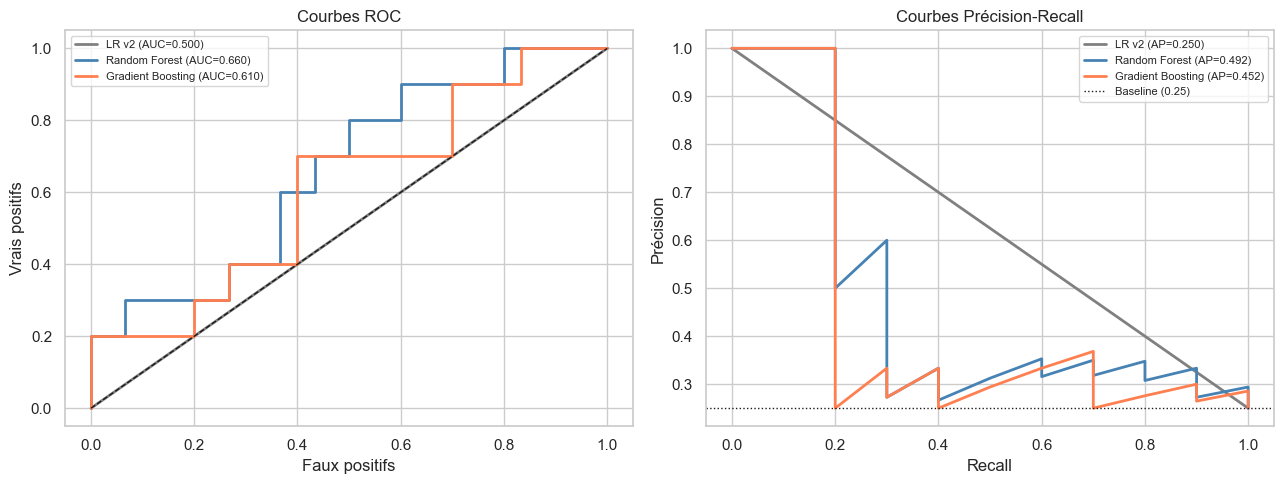

In [16]:
# Seuils optimisés sur X_val pour RF et GB
rf_thresh, _ = find_best_threshold_accuracy(
    y_val, rf_search.best_estimator_.predict_proba(X_val)[:, 1]
)
gb_thresh, _ = find_best_threshold_accuracy(
    y_val, gb_search.best_estimator_.predict_proba(X_val)[:, 1]
)

results = [
    evaluate_model_test('LR v2',            lr_v2,                    X_train, y_train,
                                             X_test, y_test, threshold=best_threshold),
    evaluate_model_test('Random Forest',    rf_search.best_estimator_, X_train, y_train,
                                             X_test, y_test, threshold=rf_thresh),
    evaluate_model_test('Gradient Boosting',gb_search.best_estimator_, X_train, y_train,
                                             X_test, y_test, threshold=gb_thresh),
]

results_df = pd.DataFrame(results).drop(columns=['_proba','_pred']).set_index('Modèle')
print('=== Comparaison finale — jeu de test ===')
print(results_df.to_string())

# Courbes ROC et Précision-Recall comparatives
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['gray', 'steelblue', 'coral']
for res, color in zip(results, colors):
    fpr, tpr, _ = roc_curve(y_test, res['_proba'])
    axes[0].plot(fpr, tpr, lw=2, color=color,
                 label=f"{res['Modèle']} (AUC={res['ROC-AUC']:.3f})")
    p, r, _ = precision_recall_curve(y_test, res['_proba'])
    axes[1].plot(r, p, lw=2, color=color,
                 label=f"{res['Modèle']} (AP={average_precision_score(y_test, res['_proba']):.3f})")

axes[0].plot([0,1],[0,1],'k--',lw=1)
axes[0].set(xlabel='Faux positifs', ylabel='Vrais positifs', title='Courbes ROC')
axes[0].legend(fontsize=8)
axes[1].axhline(y_test.mean(), color='k', linestyle=':', lw=1,
                label=f'Baseline ({y_test.mean():.2f})')
axes[1].set(xlabel='Recall', ylabel='Précision', title='Courbes Précision-Recall')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 8. Calibration du Random Forest (Platt scaling)

Les probabilités brutes du RF tendent à être trop extrêmes.  
Le Platt scaling recale les probas pour qu'elles reflètent des fréquences réelles, ce qui améliore la fiabilité du seuil de décision.

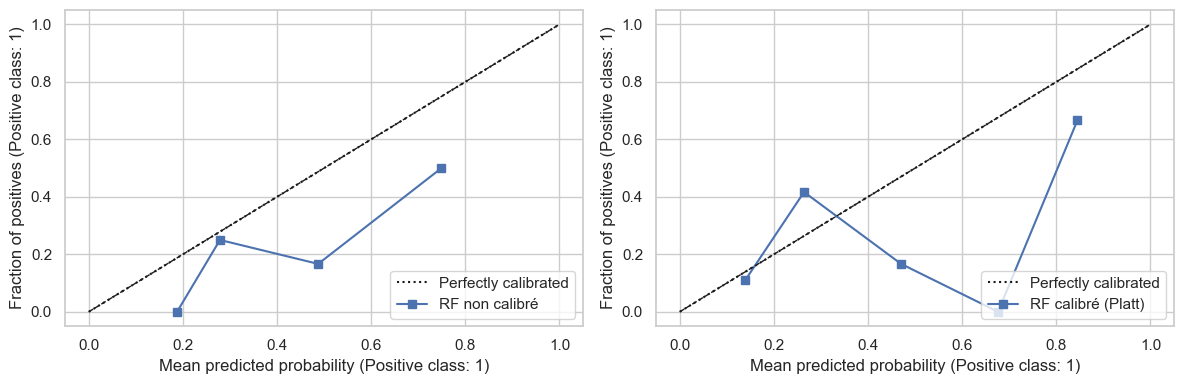

RF calibré — seuil : 0.84
              precision    recall  f1-score   support

      Refusé       0.79      1.00      0.88        30
 Sélectionné       1.00      0.20      0.33        10

    accuracy                           0.80        40
   macro avg       0.89      0.60      0.61        40
weighted avg       0.84      0.80      0.75        40

Accuracy : 0.800


In [17]:
best_rf_params = {k.replace('classifier__', ''): v
                  for k, v in rf_search.best_params_.items()}

rf_calibrated = ImbPipeline([
    ('preprocessor', build_preprocessor(NUMERIC_FEATURES_V2)),
    ('smote',        SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
    ('classifier',   CalibratedClassifierCV(
                         RandomForestClassifier(**best_rf_params, n_estimators=300,
                                               class_weight='balanced',
                                               random_state=RANDOM_STATE, n_jobs=-1),
                         method='sigmoid', cv=5,
                     )),
])
rf_calibrated.fit(X_train, y_train)
y_proba_rf_cal = rf_calibrated.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
CalibrationDisplay.from_predictions(
    y_test, rf_search.best_estimator_.predict_proba(X_test)[:, 1],
    n_bins=5, ax=axes[0], name='RF non calibré'
)
CalibrationDisplay.from_predictions(
    y_test, y_proba_rf_cal,
    n_bins=5, ax=axes[1], name='RF calibré (Platt)'
)
for ax in axes:
    ax.plot([0,1],[0,1],'k--',lw=1)
plt.tight_layout()
plt.show()

# Seuil recalculé sur les probas calibrées
rf_cal_thresh, _ = find_best_threshold_accuracy(
    y_val, rf_calibrated.predict_proba(X_val)[:, 1]
)
y_pred_rf_cal = (y_proba_rf_cal >= rf_cal_thresh).astype(int)
print(f'RF calibré — seuil : {rf_cal_thresh:.2f}')
print(classification_report(y_test, y_pred_rf_cal, target_names=['Refusé','Sélectionné']))
print(f'Accuracy : {accuracy_score(y_test, y_pred_rf_cal):.3f}')

## 9. Interprétabilité SHAP — LR v2

`LinearExplainer` fournit des valeurs SHAP exactes pour les modèles linéaires.

Estimating transforms: 100%|██████████| 1000/1000 [00:03<00:00, 316.71it/s]


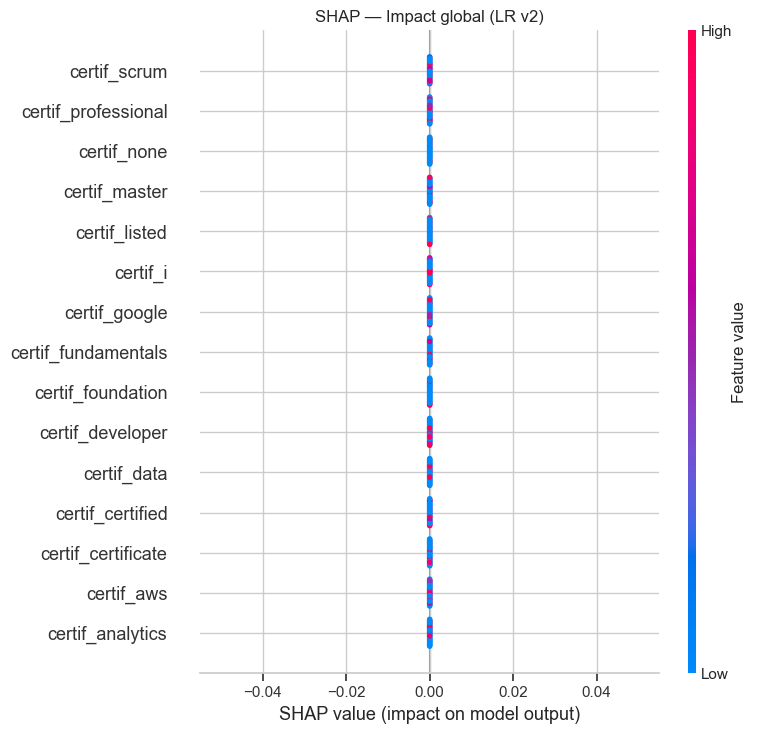

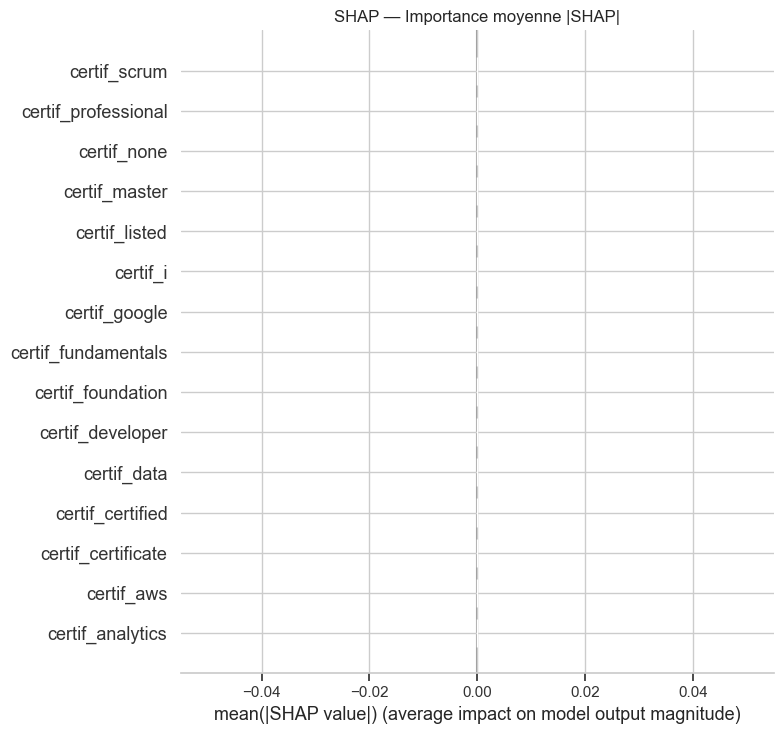

In [18]:
# Refit du préprocesseur sur train seul pour la transformation de test
preprocessor_v2_fit = build_preprocessor(NUMERIC_FEATURES_V2)
preprocessor_v2_fit.fit(X_train)
X_test_transformed = preprocessor_v2_fit.transform(X_test)

feature_names_v2 = (
    NUMERIC_FEATURES_V2
    + preprocessor_v2_fit.named_transformers_['cat']
        .named_steps['ohe'].get_feature_names_out(CATEGORICAL_FEATURES).tolist()
    + [f'skill_{w}' for w in
       preprocessor_v2_fit.named_transformers_['skills'].get_feature_names_out()]
    + [f'certif_{w}' for w in
       preprocessor_v2_fit.named_transformers_['certif'].get_feature_names_out()]
)

explainer   = shap.LinearExplainer(
    lr_v2.named_steps['classifier'],
    X_test_transformed,
    feature_perturbation='correlation_dependent',
)
shap_values = explainer.shap_values(X_test_transformed)
shap_df     = pd.DataFrame(X_test_transformed, columns=feature_names_v2)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, shap_df, max_display=15, show=False)
plt.title('SHAP — Impact global (LR v2)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, shap_df, plot_type='bar', max_display=15, show=False)
plt.title('SHAP — Importance moyenne |SHAP|')
plt.tight_layout()
plt.show()

## 10. Conclusion & modèle retenu

**Modèle retenu : LR v2 (L1/ElasticNet) + seuil optimisé sur validation**

- Régularisation L1/ElasticNet : sélection de features + robustesse sur faible volume
- Seuil calibré sur `X_val` (pas de data leakage sur le test)
- Pas de `class_weight='balanced'` sur la LR finale (nuit à l'accuracy globale)
- Random Forest : surveiller l'overfitting, probas à recalibrer avec Platt
- Gradient Boosting : potentiel si volume augmente

In [19]:
# Tableau récapitulatif final
summary_rows = []
for res in results:
    row = {k: v for k, v in res.items() if not k.startswith('_')}
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('Modèle')
print(summary_df.to_string())

                   Accuracy  Précision(1)  Recall(1)  F1(1)  ROC-AUC  Seuil
Modèle                                                                     
LR v2                 0.750         0.000        0.0  0.000     0.50   0.50
Random Forest         0.775         0.667        0.2  0.308     0.66   0.74
Gradient Boosting     0.675         0.286        0.2  0.235     0.61   0.51
